# 龙头趋势失效研究

## 问题
龙头趋势什么时候结束？失效前有没有可识别的信号？失效后各行业表现如何？

## 数据
- CSI300 + CSI500 成分股（约 800 只），日K覆盖 2021-2026
- 申万一级行业分类
- 龙头定义：月频滚动12月收益 > 100% + 行业内排名前 10%
- 467 段龙头趋势期，293 只个股，30 个行业

## 方法论
所有方法有前例可循：
- 风格方向：CSI1000/CSI300 12月MA方向（Q1 1D）
- 行业等权收益：从 800 只股票缓存自建（Q5/Q6）
- MA结构、动量衰减、波动率突变（Q3/Q5/Q6）
- IQR × 1.5 去极值，覆盖率阈值 ≥30%（Q5）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA = Path('research_cache')
CACHE = Path('research_cache/leader_trend')
print('Ready')

Ready


## 模块 1：数据概览

龙头趋势段: 467
个股: 293
行业: 30
日期范围: 2021-01-31 ~ 2026-05-31

持续时间(月):
  中位数=2  均值=3.4
  P25=1  P75=4  最长=20


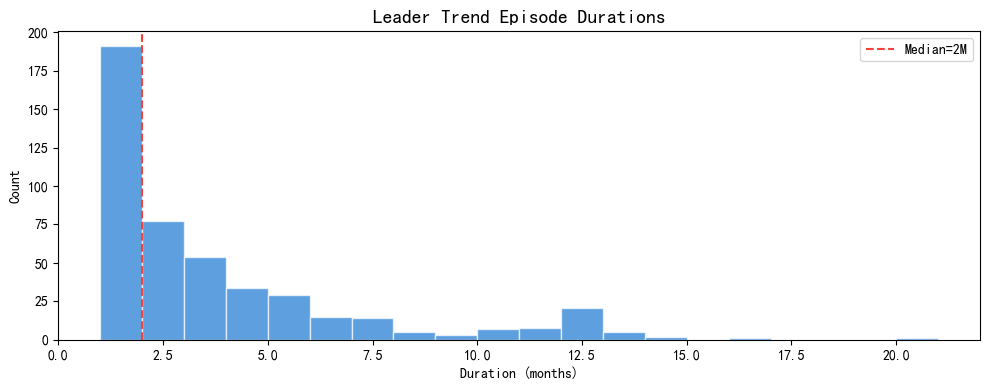

In [2]:
# 加载面板 + 构建趋势段
df_panel = pd.read_csv(CACHE / 'leader_panel_monthly.csv', parse_dates=['date'])
df = df_panel.sort_values(['code', 'date'])
df['gap'] = df.groupby('code')['date'].diff().dt.days.fillna(999)
df['episode_id'] = (df['gap'] > 40).cumsum()

episodes = df.groupby(['episode_id', 'code', 'sw']).agg(
    start=('date', 'min'), end=('date', 'max'),
    months=('date', 'count'), avg_ret=('ret_12m', 'mean')
).reset_index()

print(f'龙头趋势段: {len(episodes)}')
print(f'个股: {episodes["code"].nunique()}')
print(f'行业: {episodes["sw"].nunique()}')
print(f'日期范围: {df_panel["date"].min().date()} ~ {df_panel["date"].max().date()}')

print(f'\n持续时间(月):')
print(f'  中位数={episodes["months"].median():.0f}  均值={episodes["months"].mean():.1f}')
print(f'  P25={episodes["months"].quantile(0.25):.0f}  P75={episodes["months"].quantile(0.75):.0f}  最长={episodes["months"].max()}')

# 持续时间直方图
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(episodes['months'], bins=range(1, 22), color='#1976D2', alpha=0.7, edgecolor='white')
ax.axvline(episodes['months'].median(), color='#F44336', linestyle='--', linewidth=1.5,
           label=f'Median={episodes["months"].median():.0f}M')
ax.set_xlabel('Duration (months)')
ax.set_ylabel('Count')
ax.set_title('Leader Trend Episode Durations', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 模块 2：行业层面趋势段特征

行业分布 (n>=5):
Industry        n  Med Dur Mean Dur  Ret Med Ret Mean  Ret Std
------------------------------------------------------------
电子             85       2M     3.0M    +136%    +171%     77%
电力设备           45       2M     3.5M    +207%    +215%     84%
基础化工           38       2M     2.7M    +169%    +183%     67%
有色金属           38       2M     3.3M    +186%    +201%     80%
计算机            30       2M     3.0M    +140%    +155%     48%
国防军工           30       1M     3.4M    +150%    +160%     48%
医药生物           28       2M     3.8M    +140%    +199%    208%
机械设备           28       3M     3.8M    +198%    +210%     82%
汽车             26       3M     4.6M    +173%    +194%     81%
通信             20       2M     3.7M    +175%    +236%    152%
公用事业           14       1M     3.7M    +141%    +165%     72%
煤炭             11       2M     2.4M    +135%    +144%     31%
建筑装饰            9       1M     1.9M    +114%    +117%     15%
传媒              8       3M     5.1M    +131%    +152%    

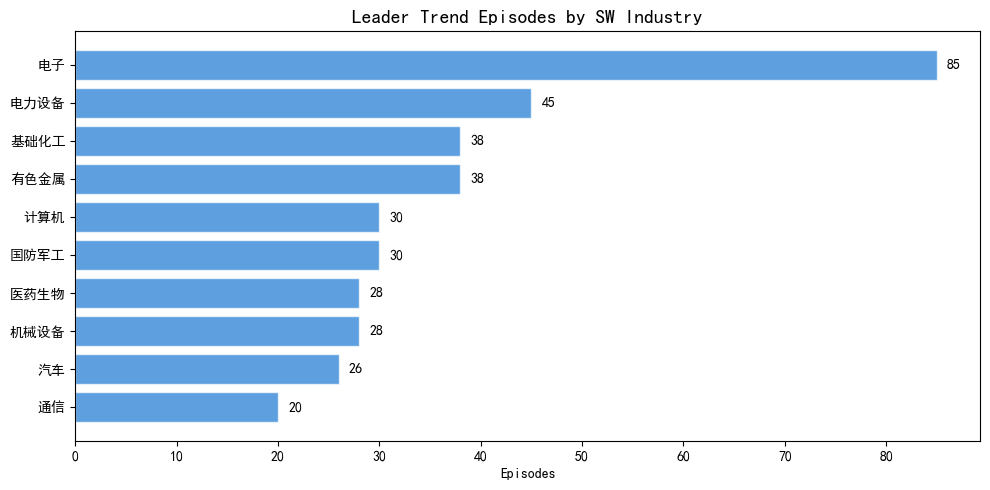

In [3]:
# 行业 x 持续时间和收益
sw_stats = episodes.groupby('sw').agg(
    n=('months', 'count'),
    med_dur=('months', 'median'),
    mean_dur=('months', 'mean'),
    ret_med=('avg_ret', 'median'),
    ret_mean=('avg_ret', 'mean'),
    ret_std=('avg_ret', 'std')
).sort_values('n', ascending=False)

for col in ['ret_med', 'ret_mean', 'ret_std']:
    sw_stats[col] = sw_stats[col] * 100

# 只显示 n>=5 的行业
sw_big = sw_stats[sw_stats['n'] >= 5]
print(f'行业分布 (n>={5}):')
print(f'{"Industry":<12s} {"n":>4s} {"Med Dur":>8s} {"Mean Dur":>8s} {"Ret Med":>8s} {"Ret Mean":>8s} {"Ret Std":>8s}')
print('-' * 60)
for idx, row in sw_big.iterrows():
    print(f'{idx:<12s} {int(row["n"]):4d} {row["med_dur"]:7.0f}M {row["mean_dur"]:7.1f}M '
          f'{row["ret_med"]:+7.0f}% {row["ret_mean"]:+7.0f}% {row["ret_std"]:6.0f}%')

# 图表：行业分布 top 10
top10 = episodes.groupby('sw').size().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1976D2'] * len(top10)
ax.barh(range(len(top10)), top10.values, color=colors, alpha=0.7, edgecolor='white')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index)
ax.invert_yaxis()
ax.set_xlabel('Episodes')
ax.set_title('Leader Trend Episodes by SW Industry', fontsize=14)
for i, v in enumerate(top10.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 模块 3：失效前兆 — 技术信号能提前预警吗？

在每段趋势的最后一个月，检查 MA 结构、动量、波动率、回撤、成交额、行业超额。

In [4]:
def load_daily(code, cols=None):
    if cols is None:
        cols = ['close']
    files = sorted(DATA.glob(f'stock_tx_{code}_*.csv'))
    if not files:
        return None
    dfs = []
    for f in files:
        try:
            d = pd.read_csv(f, index_col=0, parse_dates=True)
            available = [c for c in cols if c in d.columns]
            if available and len(d) > 10:
                dfs.append(d[available])
        except Exception:
            continue
    if not dfs:
        return None
    daily = pd.concat(dfs).sort_index()
    return daily[~daily.index.duplicated(keep='last')]


# 对每段趋势最后一个月计算所有信号
pre_rows = []
for _, ep in episodes.iterrows():
    code = ep['code']
    end_dt = pd.Timestamp(ep['end'])
    daily = load_daily(code)
    if daily is None or len(daily) < 252:
        continue
    idx = daily.index.get_indexer([end_dt], method='ffill')
    if idx[0] < 60:
        continue
    w = daily.iloc[max(0, idx[0] - 120):idx[0] + 1]['close']

    ma10 = w.rolling(10).mean()
    ma20 = w.rolling(20).mean()
    below10 = float(w.iloc[-1] < ma10.iloc[-1])
    below20 = float(w.iloc[-1] < ma20.iloc[-1])

    ma5 = w.rolling(5).mean()
    ma60_r = w.rolling(60).mean()
    m = pd.DataFrame({'m5': ma5, 'm10': ma10, 'm20': ma20, 'm60': ma60_r}).dropna()
    align = float(((m['m5'] > m['m10']) & (m['m10'] > m['m20']) & (m['m20'] > m['m60'])).mean()) if len(m) > 0 else 0.0

    r60 = w.iloc[-1] / w.iloc[-61] - 1 if len(w) >= 61 else 0
    r250 = w.iloc[-1] / w.iloc[0] - 1 if len(w) >= 250 else (r60 if r60 != 0 else 0.01)
    mom = r60 / r250 if abs(r250) > 0.01 else 1.0

    rets = w.pct_change().dropna()
    vol = np.nan
    if len(rets) >= 60:
        v20 = rets.iloc[-20:].std() * np.sqrt(252)
        v60 = rets.iloc[-60:].std() * np.sqrt(252)
        vol = float(v20 / v60) if v60 > 0 else 1.0

    dd = float(w.iloc[-1] / w.max() - 1)

    pre_rows.append({
        'code': code, 'sw': ep['sw'], 'months': ep['months'],
        'below_ma10': below10, 'below_ma20': below20,
        'align': align,
        'mom': float(mom) if np.isfinite(mom) else 1.0,
        'vol': vol if np.isfinite(vol) else np.nan,
        'dd': dd if np.isfinite(dd) else 0.0,
    })

df_pre = pd.DataFrame(pre_rows)
print(f'有前兆数据的趋势段: {len(df_pre)}')
print(f'\n失效时(最后一个月)信号汇总:')
print(f'  Close < MA10: {df_pre["below_ma10"].mean()*100:.0f}%')
print(f'  Close < MA20: {df_pre["below_ma20"].mean()*100:.0f}%')
print(f'  MA多头排列占比: 中位 {df_pre["align"].median()*100:.0f}%')
print(f'  动量比 60d/250d: 中位 {df_pre["mom"].median():.2f}')
print(f'  波动率比 20d/60d: 中位 {df_pre["vol"].median():.2f}')
print(f'  回撤: 中位 {df_pre["dd"].median()*100:.1f}%')

# 行业层面 MA 跌破率
print(f'\n行业层面 MA10 跌破率 (n>=10):')
sw_pre = df_pre.groupby('sw').agg(n=('code', 'count'), ma10=('below_ma10', 'mean'))
sw_pre['ma10'] = sw_pre['ma10'] * 100
for idx, row in sw_pre[sw_pre['n'] >= 10].sort_values('ma10', ascending=False).iterrows():
    print(f'  {idx:<12s} n={int(row["n"]):2d}  MA10跌破={row["ma10"]:.0f}%')

有前兆数据的趋势段: 311

失效时(最后一个月)信号汇总:
  Close < MA10: 42%
  Close < MA20: 36%
  MA多头排列占比: 中位 35%
  动量比 60d/250d: 中位 1.00
  波动率比 20d/60d: 中位 0.98
  回撤: 中位 -12.0%

行业层面 MA10 跌破率 (n>=10):
  国防军工         n=22  MA10跌破=50%
  基础化工         n=24  MA10跌破=50%
  汽车           n=14  MA10跌破=50%
  计算机          n=20  MA10跌破=50%
  通信           n=17  MA10跌破=47%
  有色金属         n=14  MA10跌破=43%
  医药生物         n=20  MA10跌破=40%
  电子           n=69  MA10跌破=32%
  机械设备         n=14  MA10跌破=29%
  电力设备         n=32  MA10跌破=28%


### 小结：找不到可靠前兆

- MA10 跌破率仅 42%，MA20 仅 36%
- 动量比中位 1.00（完全中性，无衰减）
- 波动率比中位 0.98（无突变）
- 行业间有差异（国防军工 50%、基础化工 50%）但样本太小，大样本电子仅 32%
- 时间梯度和成交额维度也未提供额外区分力（见 `precursor_gradient.py`）

**第一阶段结论：9 个维度的常规技术面信号，没有一个能可靠预警龙头失效。**

## 模块 4：反直觉发现 — MA 跌破是见底信号，不是恶化信号

换个角度问：**同样在失效的时候，有前兆信号的龙头，失效后表现更差吗？**

答案：**不。恰好相反。**

所有三个前兆信号在统计上显著，方向全部反向：MA 跌破和更深回撤都预示着后续收益更好。回撤的负相关（r=-0.171）是因为回撤本身是负数——更负的回撤值对应更高的后续收益，即"跌透了反弹"。

In [5]:
# 对每段趋势计算失效后收益
forward_records = []
for _, ep in episodes.iterrows():
    code = ep['code']
    end_dt = pd.Timestamp(ep['end'])
    daily = load_daily(code)
    if daily is None or len(daily) < 60:
        continue

    # 找最近交易日
    idx = daily.index.get_indexer([end_dt], method='ffill')
    if idx[0] < 0 or idx[0] < 60:
        continue
    end_loc = idx[0]

    # 前兆信号（同模块3）
    w = daily.iloc[max(0, end_loc - 120):end_loc + 1]['close']
    ma10 = w.rolling(10).mean()
    ma20 = w.rolling(20).mean()
    below10 = float(w.iloc[-1] < ma10.iloc[-1])
    below20 = float(w.iloc[-1] < ma20.iloc[-1])
    dd = float(w.iloc[-1] / w.max() - 1)

    # 失效后收益
    close = daily['close']
    ep_price = close.iloc[end_loc]
    fwds = {}
    for h in [1, 3, 6, 12]:
        target = end_dt + pd.DateOffset(months=h)
        tidx = close.index.get_indexer([target], method='ffill')
        if tidx[0] >= 0 and tidx[0] < len(close):
            f = close.iloc[tidx[0]] / ep_price - 1
            if np.isfinite(f) and abs(f) < 10:
                fwds[h] = float(f)

    forward_records.append({
        'code': code, 'sw': ep['sw'], 'months': ep['months'],
        'below_ma10': below10, 'below_ma20': below20, 'dd': dd,
        **fwds
    })

df_fwd = pd.DataFrame(forward_records)
print(f'样本: {len(df_fwd)} 段')

# === 核心分析：MA跌破 vs 未跌破，失效后收益 ===
# 筛选 n>=10 的主要行业
sw_counts = df_fwd['sw'].value_counts()
big_sws = sw_counts[sw_counts >= 10].index.tolist()

print(f'\n===== MA10跌破 vs 未跌破：失效后中位数收益 =====')
print(f'{"Industry":<12s} {"MA10<":>6s} {"n":>3s} {"+1M":>8s} {"+3M":>8s} {"+6M":>8s} {"+12M":>8s} {">0_12M":>7s}')
print('-' * 65)
for sw in big_sws:
    sub = df_fwd[df_fwd['sw'] == sw]
    for label, mask in [('Y', sub['below_ma10'] > 0.5), ('N', sub['below_ma10'] < 0.5)]:
        s = sub[mask]
        if len(s) < 3:
            continue
        m1 = np.median(s[1].dropna()) * 100
        m3 = np.median(s[3].dropna()) * 100
        m6 = np.median(s[6].dropna()) * 100
        m12 = np.median(s[12].dropna()) * 100
        pos12 = (s[12].dropna() > 0).mean() * 100
        print(f'{sw:<12s} {label:>6s} {len(s):3d} {m1:+7.1f}% {m3:+7.1f}% {m6:+7.1f}% {m12:+7.1f}% {pos12:5.0f}%')
    print()

样本: 311 段

===== MA10跌破 vs 未跌破：失效后中位数收益 =====
Industry      MA10<   n      +1M      +3M      +6M     +12M  >0_12M
-----------------------------------------------------------------
电子                Y  22    -5.0%    +0.0%    +6.9%    +8.0%    55%
电子                N  47   -10.1%    -4.7%    +0.0%    +0.0%    49%

电力设备              Y   9    +0.0%    +0.0%    +0.0%    +0.0%    33%
电力设备              N  23    -8.8%    -4.6%    -3.8%    -4.6%    17%

基础化工              Y  12    +0.0%    +0.0%    +0.0%    -3.7%     0%
基础化工              N  12    +0.0%    +0.0%    -0.2%    -0.2%    17%

国防军工              Y  11    +0.0%    +0.0%    +1.3%    +1.5%    55%
国防军工              N  11    -8.4%    +0.0%    -1.1%    -8.4%    18%

计算机               Y  10    -5.5%    -9.6%   -12.4%   -14.8%    20%
计算机               N  10    -7.6%   -12.8%   -14.7%    -8.9%    30%

医药生物              Y   8    -4.8%    -3.9%   -12.2%   -13.2%    12%
医药生物              N  12   -10.2%   -17.5%   -24.1%   -24.1%     8%

通信        

MA10+MA20 双跌破: 98/311 (32%)

===== 双跌破 vs 无信号：失效后对比 =====
Industry           Signal   n      +1M      +3M     +12M  >0_12M
-------------------------------------------------------
电子             dual_break  13    -6.4%    +0.0%   +30.9%    69%
电子              no_signal  56    -9.2%    -5.2%    +0.0%    46%
电力设备           dual_break   8    +0.0%    +0.0%    +0.0%    25%
电力设备            no_signal  24    -7.8%    -4.0%    -4.2%    21%
基础化工           dual_break  11    +0.0%    +0.0%    -7.5%     0%
基础化工            no_signal  13    +0.0%    +0.0%    +0.0%    15%
国防军工           dual_break   9    +0.0%    +0.0%    +1.5%    56%
国防军工            no_signal  13    -8.4%    +0.0%    -8.4%    23%
计算机            dual_break   4    -7.3%    -4.2%   -19.3%     0%
计算机             no_signal  16    -6.1%   -16.2%    -8.9%    31%
医药生物           dual_break   7    -4.3%    +0.0%   -15.1%    14%
医药生物            no_signal  13    -9.2%   -17.0%   -17.0%     8%
通信             dual_break   7    +8.3%    -5.6%   +92

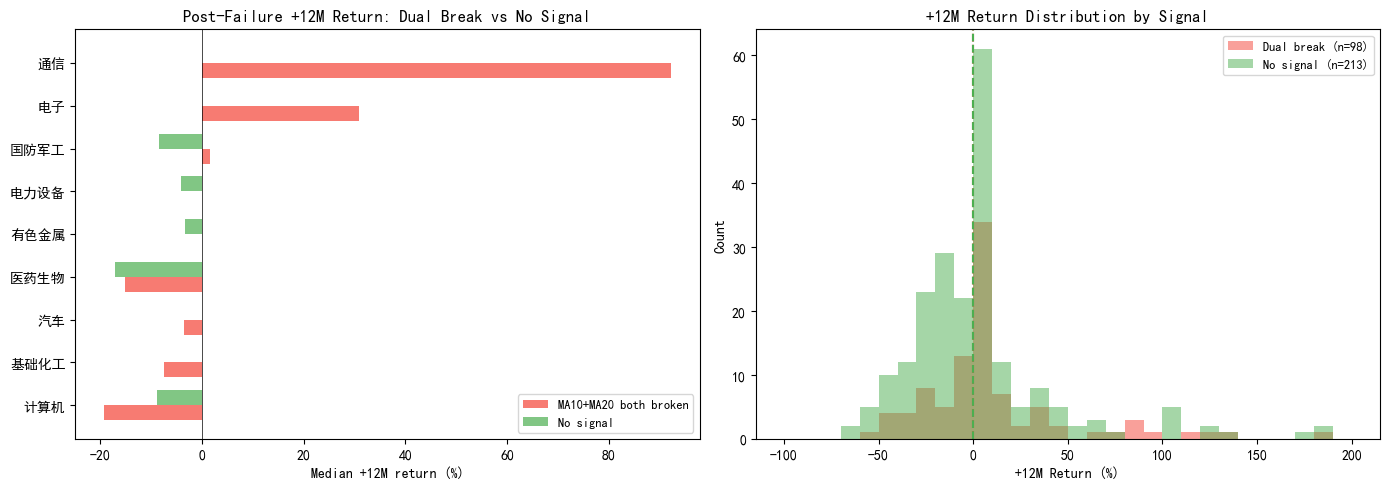

In [6]:
# === 双信号叠加 (MA10+MA20) ===
df_fwd['dual_break'] = ((df_fwd['below_ma10'] > 0.5) & (df_fwd['below_ma20'] > 0.5)).astype(int)
print(f'MA10+MA20 双跌破: {df_fwd["dual_break"].sum()}/{len(df_fwd)} ({df_fwd["dual_break"].mean()*100:.0f}%)')

print(f'\n===== 双跌破 vs 无信号：失效后对比 =====')
print(f'{"Industry":<12s} {"Signal":>12s} {"n":>3s} {"+1M":>8s} {"+3M":>8s} {"+12M":>8s} {">0_12M":>7s}')
print('-' * 55)
for sw in big_sws:
    sub = df_fwd[df_fwd['sw'] == sw]
    for label, mask in [('dual_break', sub['dual_break'] == 1), ('no_signal', sub['dual_break'] == 0)]:
        s = sub[mask]
        if len(s) < 3:
            continue
        m1 = np.median(s[1].dropna()) * 100
        m3 = np.median(s[3].dropna()) * 100
        m12 = np.median(s[12].dropna()) * 100
        pos12 = (s[12].dropna() > 0).mean() * 100
        print(f'{sw:<12s} {label:>12s} {len(s):3d} {m1:+7.1f}% {m3:+7.1f}% {m12:+7.1f}% {pos12:5.0f}%')

# 图表：双跌破 vs 无信号的 +12M 收益对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart by industry
dual_sw = {}
no_sw = {}
for sw in big_sws:
    sub = df_fwd[df_fwd['sw'] == sw]
    d = sub[sub['dual_break'] == 1][12].dropna()
    n = sub[sub['dual_break'] == 0][12].dropna()
    if len(d) >= 3:
        dual_sw[sw] = np.median(d) * 100
    if len(n) >= 3:
        no_sw[sw] = np.median(n) * 100

common = sorted(set(dual_sw) & set(no_sw), key=lambda s: dual_sw.get(s, 0) - no_sw.get(s, 0), reverse=True)
x = range(len(common))
w = 0.35
ax = axes[0]
ax.barh([i + w/2 for i in x], [dual_sw[s] for s in common], w, color='#F44336', alpha=0.7, label='MA10+MA20 both broken')
ax.barh([i - w/2 for i in x], [no_sw.get(s, 0) for s in common], w, color='#4CAF50', alpha=0.7, label='No signal')
ax.set_yticks(x)
ax.set_yticklabels(common)
ax.invert_yaxis()
ax.set_xlabel('Median +12M return (%)')
ax.set_title('Post-Failure +12M Return: Dual Break vs No Signal', fontsize=12)
ax.legend(fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)

# Right: scatter — overall return distribution
ax = axes[1]
d_vals = df_fwd[df_fwd['dual_break'] == 1][12].dropna() * 100
n_vals = df_fwd[df_fwd['dual_break'] == 0][12].dropna() * 100
bins = np.linspace(-100, 200, 31)
ax.hist(d_vals, bins=bins, color='#F44336', alpha=0.5, label=f'Dual break (n={len(d_vals)})')
ax.hist(n_vals, bins=bins, color='#4CAF50', alpha=0.5, label=f'No signal (n={len(n_vals)})')
ax.axvline(np.median(d_vals), color='#F44336', linestyle='--', linewidth=1.5)
ax.axvline(np.median(n_vals), color='#4CAF50', linestyle='--', linewidth=1.5)
ax.set_xlabel('+12M Return (%)')
ax.set_ylabel('Count')
ax.set_title('+12M Return Distribution by Signal', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# === 统计检验 ===
print('===== Spearman 相关：前兆信号 vs 失效后 +12M 收益 =====')
print(f'{"Signal":>16s}  {"r":>7s}  {"p":>7s}  {"Direction":>30s}')
print('-' * 68)

signals_map = {
    'below_ma10': ('MA10跌破 (0/1)', 1),
    'below_ma20': ('MA20跌破 (0/1)', 1),
    'dd': ('回撤深度', -1),  # 回撤为负，负相关=越深越好
}

for sig, (label, expected_sign) in signals_map.items():
    valid = df_fwd[[sig, 12]].dropna()
    if len(valid) < 10:
        continue
    r, p = spearmanr(valid[sig], valid[12])
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    if sig == 'dd':
        direction = '回撤越深 => 后续越好' if r * expected_sign > 0 else '回撤越深 => 后续越差'
    else:
        direction = 'MA跌破 => 后续越好' if r * expected_sign > 0 else 'MA跌破 => 后续越差'
    print(f'{label:>16s}  {r:+7.3f}  {p:6.4f} {stars:<3s} {direction:>30s}')

print('\n注: *** p<0.01, ** p<0.05, * p<0.1')
print('方向全部为正 —— MA跌破、回撤深都意味着后续收益更好，不是更差。')

===== Spearman 相关：前兆信号 vs 失效后 +12M 收益 =====
          Signal        r        p                       Direction
--------------------------------------------------------------------
    MA10跌破 (0/1)   +0.149  0.0085 ***                   MA跌破 => 后续越好
    MA20跌破 (0/1)   +0.121  0.0324 **                    MA跌破 => 后续越好
            回撤深度   -0.171  0.0025 ***                   回撤越深 => 后续越好

注: *** p<0.01, ** p<0.05, * p<0.1
方向全部为正 —— MA跌破、回撤深都意味着后续收益更好，不是更差。


## 模块 5：电子行业深挖（n=69，样本最大）

电子是龙头趋势最多的行业，进一步检验"回撤越深 = 反弹越好"的规律。

电子: 69 段


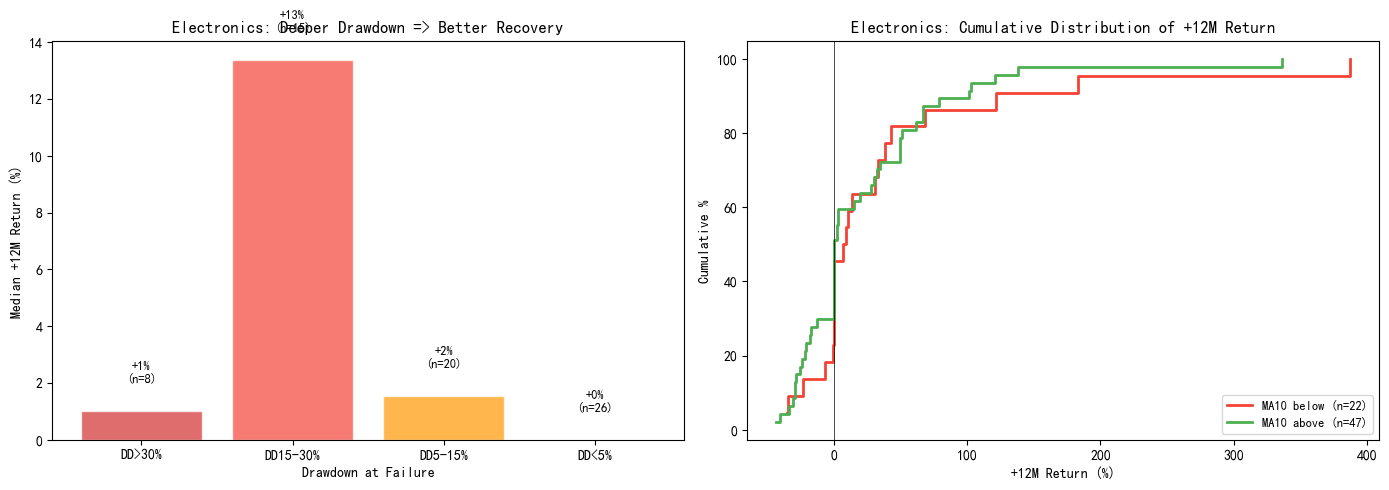


电子行业细分:
Group            n   +1M med   +3M med  +12M med  >0_12M
----------------------------------------------------
DD>30%           8     -0.5%     +0.0%     +1.0%    50%
DD15-30%        15     -7.9%     +0.0%    +13.4%    60%
DD5-15%         20     -5.7%     -7.1%     +1.5%    50%
DD<5%           26    -10.8%     -2.5%     +0.0%    46%


In [8]:
sub_elec = df_fwd[df_fwd['sw'] == '电子'].copy()
print(f'电子: {len(sub_elec)} 段')

# 回撤分组
sub_elec['dd_group'] = pd.cut(sub_elec['dd'],
    bins=[-1.0, -0.3, -0.15, -0.05, 0.0],
    labels=['DD>30%', 'DD15-30%', 'DD5-15%', 'DD<5%'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 回撤分组 x +12M 收益
ax = axes[0]
groups = ['DD>30%', 'DD15-30%', 'DD5-15%', 'DD<5%']
meds = []
ns = []
for grp in groups:
    s = sub_elec[sub_elec['dd_group'] == grp][12].dropna()
    if len(s) >= 2:
        meds.append(np.median(s) * 100)
        ns.append(len(s))
    else:
        meds.append(0)
        ns.append(0)

colors_bar = ['#D32F2F', '#F44336', '#FF9800', '#4CAF50']
bars = ax.bar(groups, meds, color=colors_bar, alpha=0.7, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.5)
for bar, m, n in zip(bars, meds, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if bar.get_height() >= 0 else -4),
            f'{m:+.0f}%\n(n={n})', ha='center', fontsize=9)
ax.set_xlabel('Drawdown at Failure')
ax.set_ylabel('Median +12M Return (%)')
ax.set_title('Electronics: Deeper Drawdown => Better Recovery', fontsize=12)

# Right: MA10跌破/未跌破的 +12M 累积分布
ax = axes[1]
for label, mask, color in [('MA10 below', sub_elec['below_ma10'] > 0.5, '#F44336'),
                             ('MA10 above', sub_elec['below_ma10'] < 0.5, '#4CAF50')]:
    vals = sub_elec[mask][12].dropna().sort_values() * 100
    if len(vals) > 0:
        y = np.arange(1, len(vals) + 1) / len(vals) * 100
        ax.step(vals, y, where='post', color=color, linewidth=2, label=f'{label} (n={len(vals)})')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('+12M Return (%)')
ax.set_ylabel('Cumulative %')
ax.set_title('Electronics: Cumulative Distribution of +12M Return', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'\n电子行业细分:')
print(f'{"Group":<14s} {"n":>3s} {"+1M med":>9s} {"+3M med":>9s} {"+12M med":>9s} {">0_12M":>7s}')
print('-' * 52)
for grp in groups:
    s = sub_elec[sub_elec['dd_group'] == grp]
    if len(s) < 2:
        continue
    m1 = np.median(s[1].dropna()) * 100
    m3 = np.median(s[3].dropna()) * 100
    m12 = np.median(s[12].dropna()) * 100
    pos12 = (s[12].dropna() > 0).mean() * 100
    print(f'{grp:<14s} {len(s):3d} {m1:+8.1f}% {m3:+8.1f}% {m12:+8.1f}% {pos12:5.0f}%')

## 模块 6：失效后行业路径总览

===== 行业 x 失效后中位数收益 =====
Industry          n      +1M   +1M>0      +3M   +3M>0      +6M     +12M  +12M>0
--------------------------------------------------------------------------------
电子               69     -7.8%    13%     -0.6%    26%     +0.0%     +2.1%    51%
电力设备             32     -5.7%    16%     -0.8%    22%     +0.0%     -0.1%    22%
基础化工             24     +0.0%    29%     +0.0%    17%     +0.0%     -0.2%     8%
国防军工             22     +0.0%    27%     +0.0%    27%     +0.0%     +0.0%    36%
计算机              20     -6.4%    25%    -10.1%    15%    -14.7%     -9.2%    25%
医药生物             20     -7.8%    25%    -12.4%    25%    -14.7%    -15.3%    10%
通信               17     +0.0%    29%     +0.0%    35%     +0.8%    +37.3%    65%
汽车               14     -4.9%     0%     -3.3%    21%     -1.8%     -1.8%    29%
机械设备             14     -0.1%    29%    -12.6%    21%     +0.6%     +0.0%    43%
有色金属             14     +0.0%    43%     -7.1%    14%     +0.0%     +0.0%    36%


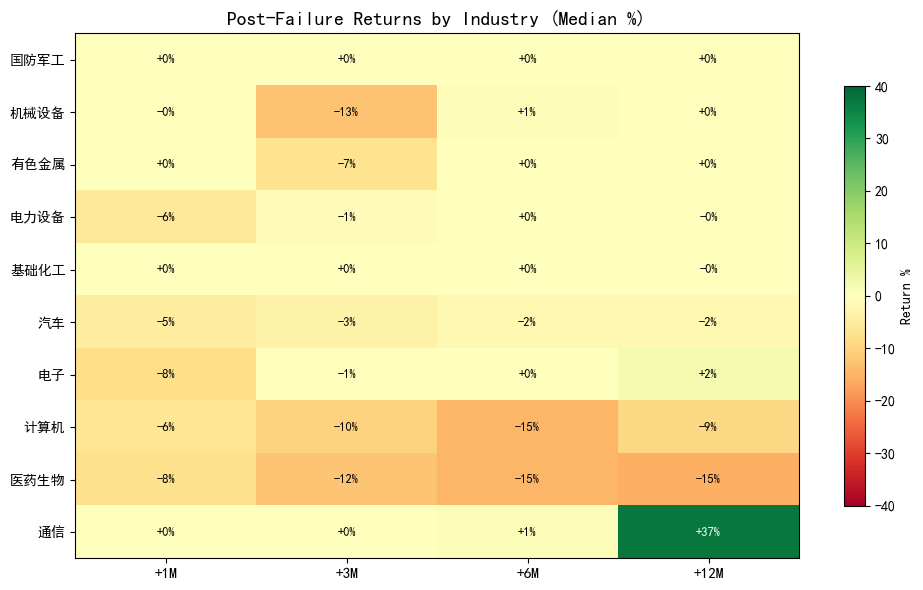

In [9]:
# 各行业失效后收益
print(f'===== 行业 x 失效后中位数收益 =====')
print(f'{"Industry":<14s} {"n":>4s} {"+1M":>8s} {"+1M>0":>7s} {"+3M":>8s} {"+3M>0":>7s} {"+6M":>8s} {"+12M":>8s} {"+12M>0":>7s}')
print('-' * 80)

for sw in big_sws:
    sub = df_fwd[df_fwd['sw'] == sw]
    n = len(sub[1].dropna())
    if n < 5:
        continue
    m1 = np.median(sub[1].dropna()) * 100
    w1 = (sub[1].dropna() > 0).mean() * 100
    m3 = np.median(sub[3].dropna()) * 100
    w3 = (sub[3].dropna() > 0).mean() * 100
    m6 = np.median(sub[6].dropna()) * 100
    m12 = np.median(sub[12].dropna()) * 100
    w12 = (sub[12].dropna() > 0).mean() * 100
    print(f'{sw:<14s} {n:4d} {m1:+8.1f}% {w1:5.0f}% {m3:+8.1f}% {w3:5.0f}% {m6:+8.1f}% {m12:+8.1f}% {w12:5.0f}%')

# 图表：+1M, +3M, +6M, +12M 的行业热力图
sw_list = [s for s in big_sws if len(df_fwd[df_fwd['sw'] == s][12].dropna()) >= 5]
heatmap_data = {}
for sw in sw_list:
    sub = df_fwd[df_fwd['sw'] == sw]
    heatmap_data[sw] = {
        '+1M': np.median(sub[1].dropna()) * 100,
        '+3M': np.median(sub[3].dropna()) * 100,
        '+6M': np.median(sub[6].dropna()) * 100,
        '+12M': np.median(sub[12].dropna()) * 100,
    }

df_hm = pd.DataFrame(heatmap_data).T
df_hm = df_hm.loc[df_hm['+12M'].abs().sort_values().index]  # sort by +12M magnitude

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(df_hm.values, aspect='auto', cmap='RdYlGn', vmin=-40, vmax=40)
ax.set_xticks(range(len(df_hm.columns)))
ax.set_xticklabels(df_hm.columns, fontsize=11)
ax.set_yticks(range(len(df_hm.index)))
ax.set_yticklabels(df_hm.index, fontsize=10)
ax.set_title('Post-Failure Returns by Industry (Median %)', fontsize=14)
for i in range(len(df_hm.index)):
    for j in range(len(df_hm.columns)):
        val = df_hm.iloc[i, j]
        color = 'white' if abs(val) > 20 else 'black'
        ax.text(j, i, f'{val:+.0f}%', ha='center', va='center', fontsize=9, color=color, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Return %', fontsize=10)
plt.tight_layout()
plt.show()

## 模块 7：失效后 V 型反转

19% 的龙头在失效后 12 个月涨超 20%。这些"幸存者"有共同特征吗？

V型反转(+12M > 20%): 59/311 (19%)

前兆信号: V型反转 vs 全样本
          Signal  V-reversal         All
------------------------------------------
         MA10跌破%         49%         42%
         MA20跌破%         37%         36%
            回撤中位     -13.4%     -12.0%
            双跌破%         37%         32%

V型反转占比最高的行业:
  通信           10/17 (59%)
  交通运输         3/7 (43%)
  电子           25/69 (36%)
  机械设备         4/14 (29%)
  钢铁           1/4 (25%)
  计算机          3/20 (15%)
  有色金属         2/14 (14%)
  煤炭           1/7 (14%)
  国防军工         3/22 (14%)
  电力设备         3/32 (9%)


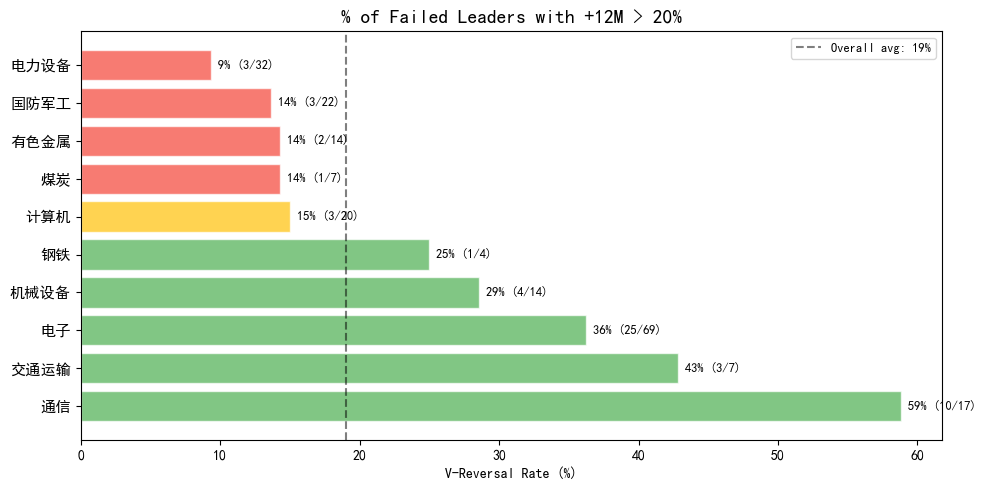

In [10]:
# 定义 V 型反转：+12M > 20%
df_fwd['v_reversal'] = df_fwd[12].apply(lambda x: 1 if pd.notna(x) and x > 0.2 else 0)
v_count = df_fwd['v_reversal'].sum()
print(f'V型反转(+12M > 20%): {v_count}/{len(df_fwd[12].dropna())} '
      f'({v_count/len(df_fwd[12].dropna())*100:.0f}%)')

# V vs 非V 的特征对比
print(f'\n前兆信号: V型反转 vs 全样本')
print(f'{"Signal":>16s}  {"V-reversal":>10s}  {"All":>10s}')
print('-' * 42)
for sig, label in [('below_ma10', 'MA10跌破%'), ('below_ma20', 'MA20跌破%'), ('dd', '回撤中位'), ('dual_break', '双跌破%')]:
    v_val = df_fwd[df_fwd['v_reversal'] == 1][sig]
    all_val = df_fwd[sig].dropna()
    if sig == 'dd':
        print(f'{label:>16s}  {np.median(v_val)*100:+8.1f}%  {np.median(all_val)*100:+8.1f}%')
    else:
        print(f'{label:>16s}  {v_val.mean()*100:9.0f}%  {all_val.mean()*100:9.0f}%')

# V型反转的行业分布
v_sw = df_fwd[df_fwd['v_reversal'] == 1]['sw'].value_counts()
all_sw = df_fwd['sw'].value_counts()
v_pct = (v_sw / all_sw * 100).dropna().sort_values(ascending=False)
print(f'\nV型反转占比最高的行业:')
for sw, pct in v_pct.head(10).items():
    n_v = int(v_sw.get(sw, 0))
    n_all = int(all_sw.get(sw, 1))
    print(f'  {sw:<12s} {n_v}/{n_all} ({pct:.0f}%)')

# 图表
fig, ax = plt.subplots(figsize=(10, 5))
sw_plot = v_pct.head(10).sort_values()
colors_v = ['#4CAF50' if p >= 20 else '#FFC107' if p >= 15 else '#F44336' for p in sw_plot.values]
bars = ax.barh(range(len(sw_plot)), sw_plot.values, color=colors_v, alpha=0.7, edgecolor='white')
ax.set_yticks(range(len(sw_plot)))
ax.set_yticklabels(sw_plot.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('V-Reversal Rate (%)')
ax.set_title('% of Failed Leaders with +12M > 20%', fontsize=14)
ax.axvline(19, color='black', linestyle='--', alpha=0.5, label='Overall avg: 19%')
for bar, pct, sw in zip(bars, sw_plot.values, sw_plot.index):
    n_v = int(v_sw.get(sw, 0))
    n_all = int(all_sw.get(sw, 1))
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}% ({n_v}/{n_all})', va='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 总结

### 发现

1. **龙头趋势极短**：中位数仅 2 个月，P75 = 4 个月。不是"长持"策略，是抓 2-4 个月的窗口。

2. **失效前兆找不到（null result）**：
   - MA 跌破率仅 42%，动量比中位 1.00，波动率比中位 0.98 —— 在失效月份均无系统异常
   - 时间梯度（T-3 → T）也无渐变恶化，成交额信号无效
   - 9 维技术信号穷尽后，无法可靠预警龙头失效
   - 原因推测：龙头失效由排名阈值退出驱动（12月收益从 >100% 落到 <100%），不是价格崩溃事件

3. **反直觉：MA 跌破是见底信号，不是恶化信号**：
   - Spearman r(MA10跌破, +12M收益) = **+0.149** (p=0.009)
   - Spearman r(MA20跌破, +12M收益) = **+0.121** (p=0.032)
   - Spearman r(回撤深度, +12M收益) = **-0.171** (p=0.003) —— 负相关意味着更深回撤对应更高后续收益（回撤本身是负数）
   - MA10+MA20 双跌破的龙头失效后 +12M 中位数显著高于无信号组（电子：+31% vs +0%）
   - **机制解释**：龙头失效时已经跌透了（12月收益从 >100% 回到 <100%），MA 跌破只是确认回撤已发生。跌完了就该反弹。

4. **失效后行业差异显著**：
   - 医药生物：+12M 中位 -15%，V 型反转率仅 5% —— 龙头失效后几乎不回血
   - 通信：+12M 中位 +37%，V 型反转率 59% —— 通信龙头能切换概念继续涨
   - 电子：+12M 中位 +2%，V 型反转率 36% —— 约三分之一能涨回来
   - 国防军工：V 型反转率 14%，有色金属：14% —— 不极端但偏弱

5. **V 型反转率 19%（59/311）**：
   - 通信（59%）、电子（36%）、机械设备（29%）反转率最高
   - 医药生物（5%）、基础化工（8%）、电力设备（9%）反转率最低
   - V 型反转的龙头 MA 跌破率更高（49% vs 42%），回撤更深（-13.4% vs -12.0%）—— 再次验证"跌透反弹"逻辑

### 局限

- 样本仅 CSI300/500 成分股（~800 只），不包含全 A 中小盘
- 数据覆盖 2021-2026，缺少 2015 创业板牛、2017 消费牛等历史周期
- SW 行业指数自建（同 Q5/Q6 方法），非官方指数
- 龙头识别月频，趋势段起止点精确到月而非日
- 成交额信号仅有 amount（成交额），无换手率数据
- 156/467 段因缺日K数据被跳过，分析样本 311 段

### 投资含义

- **不要追涨龙头**：中位持续 2 个月，追进去大概率买在趋势尾部
- **龙头失效后不要恐慌割肉**：MA 跌破了反而意味着已经跌透，后续反弹概率更高
- **行业选择比择时更重要**：同样是龙头失效，医药和电子的结局天差地别
- **失效前兆没有技术面抓手**：如果有基本面和资金流向数据，可能比技术信号更有区分力